In [18]:
from PIL import Image
import math

# bitfile_to_bw_image.py
# Usage: put this cell at index 0 in your notebook and run it.
# Reads a packed bitfile (8 pixels per byte) and writes a black/white image.
# Parameters:
#   bitfile_path: path to input file containing packed bits (MSB-first by default)
#   width: image width in pixels
#   out_path: optional path to save the resulting image (PNG recommended)
#   msb_first: True if the first pixel is in the MSB of each byte (common); False for LSB-first
#   invert: True to invert bits (1 -> 0, 0 -> 255)
# Returns a PIL Image object.


def bitfile_to_bw_image(bitfile_path, width, out_path=None, msb_first=True, invert=False):
    if width <= 0:
        raise ValueError("width must be a positive integer")
    with open(bitfile_path, "rb") as f:
        data = f.read()
    total_bits = len(data) * 8
    if total_bits == 0:
        raise ValueError("input file is empty")
    height = math.ceil(total_bits / width)
    needed_bits = height * width

    # extract bits into a flat list of 0/1
    bits = []
    for b in data:
        if msb_first:
            for shift in range(7, -1, -1):
                bits.append((b >> shift) & 1)
        else:
            for shift in range(8):
                bits.append((b >> shift) & 1)

    # pad with zeros if file doesn't exactly fill the rectangle
    if len(bits) < needed_bits:
        bits.extend([0] * (needed_bits - len(bits)))
    else:
        bits = bits[:needed_bits]

    # convert to 0..255 grayscale: 0 -> black, 1 -> white (invert if requested)
    if invert:
        pixels = [0 if bit else 255 for bit in bits]
    else:
        pixels = [255 if bit else 0 for bit in bits]

    # build image (row-major)
    img = Image.new("L", (width, height))
    img.putdata(pixels)

    if out_path:
        img.save(out_path)
    return img

# Example usage:
# img = bitfile_to_bw_image("example.bits", width=256, out_path="out.png", msb_first=True)
# display(img)  # in notebook

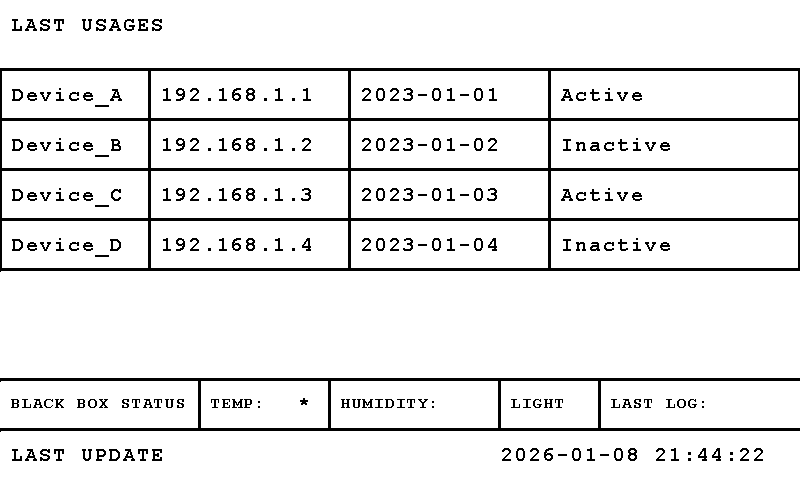

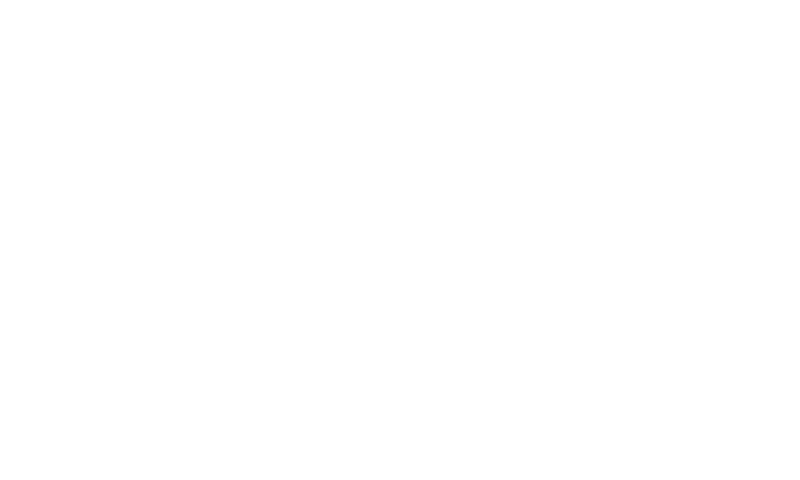

In [50]:
img = bitfile_to_bw_image("../build/blackImage.txt", width=800, out_path="blackImage.png", msb_first=True)
imgred = bitfile_to_bw_image("../build/redImage.txt", width=800, out_path="redImage.png", msb_first=True)

display(img)  # in notebook
display(imgred)  # in notebook